# Diabetes Prediction - Organized Machine Learning Pipeline

In [2]:

# ============================================
# Import Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

# Machine Learning Models
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

import warnings
warnings.filterwarnings('ignore')


c:\Users\DELL\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:

# ============================================
# Load Dataset
# ============================================

# Update the dataset path if needed
df = pd.read_csv(r'C:\Users\DELL\Desktop\New folder\diabetes_prediction_dataset.csv (1) (1).zip')

print(df.head())
print(df.shape)


   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  
(100000, 9)


In [4]:

# ============================================
# Basic Dataset Information
# ============================================

print(df.info())
print(df.describe())
print(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 8.0 MB
None
                 age  hypertension  heart_disease            bmi  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean       41.885856       0.07485       0.039420      27.320767   
std        22.516840       0.26315       0.194593       6.636783   
min   

In [5]:

# ============================================
# Remove Duplicates
# ============================================

print("Before:", df.shape)

df = df.drop_duplicates()

print("After:", df.shape)


Before: (100000, 9)
After: (96146, 9)


In [6]:

# ============================================
# Encode Categorical Columns
# ============================================

le_gender = LabelEncoder()
le_smoking = LabelEncoder()

df['gender'] = le_gender.fit_transform(df['gender'])
df['smoking_history'] = le_smoking.fit_transform(df['smoking_history'])

print(df.head())


   gender   age  hypertension  heart_disease  smoking_history    bmi  \
0       0  80.0             0              1                4  25.19   
1       0  54.0             0              0                0  27.32   
2       1  28.0             0              0                4  27.32   
3       0  36.0             0              0                1  23.45   
4       1  76.0             1              1                1  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


In [7]:

# ============================================
# Feature / Target Split
# ============================================

X = df.drop('diabetes', axis=1)
y = df['diabetes']

print(X.shape)
print(y.shape)


(96146, 8)
(96146,)


In [8]:

# ============================================
# Train Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)


(76916, 8)
(19230, 8)


In [9]:

# ============================================
# Feature Scaling
# ============================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [10]:

# ============================================
# Handle Class Imbalance using SMOTE
# ============================================

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(pd.Series(y_train_smote).value_counts())


diabetes
0    70130
1    70130
Name: count, dtype: int64


In [11]:

# ============================================
# Train 10 Machine Learning Algorithms
# ============================================

models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Gaussian NB': GaussianNB(),
    'Linear SVC': LinearSVC(max_iter=5000),
    'SGD Classifier': SGDClassifier(loss='hinge', random_state=42)
}

results = []

for name, model in models.items():

    model.fit(X_train_smote, y_train_smote)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    results.append({
        'Model': name,
        'Accuracy': round(accuracy * 100, 2),
        'Precision': round(precision * 100, 2),
        'Recall': round(recall * 100, 2),
        'F1 Score': round(f1 * 100, 2)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by='Accuracy', ascending=False)

results_df


,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,95.94,78.40,74.47,76.38
5,Extra Trees,95.54,75.12,73.88,74.49
3,Gradient Boosting,95.24,70.26,79.83,74.74
6,KNN,90.96,49.22,79.72,60.86
1,Decision Tree,89.36,44.72,87.74,59.25
4,AdaBoost,89.27,44.59,89.09,59.43
9,SGD Classifier,88.88,43.47,86.97,57.97
7,Gaussian NB,88.51,41.73,76.36,53.97
8,Linear SVC,88.39,42.35,87.50,57.08
0,Logistic Regression,88.38,42.31,87.32,57.01


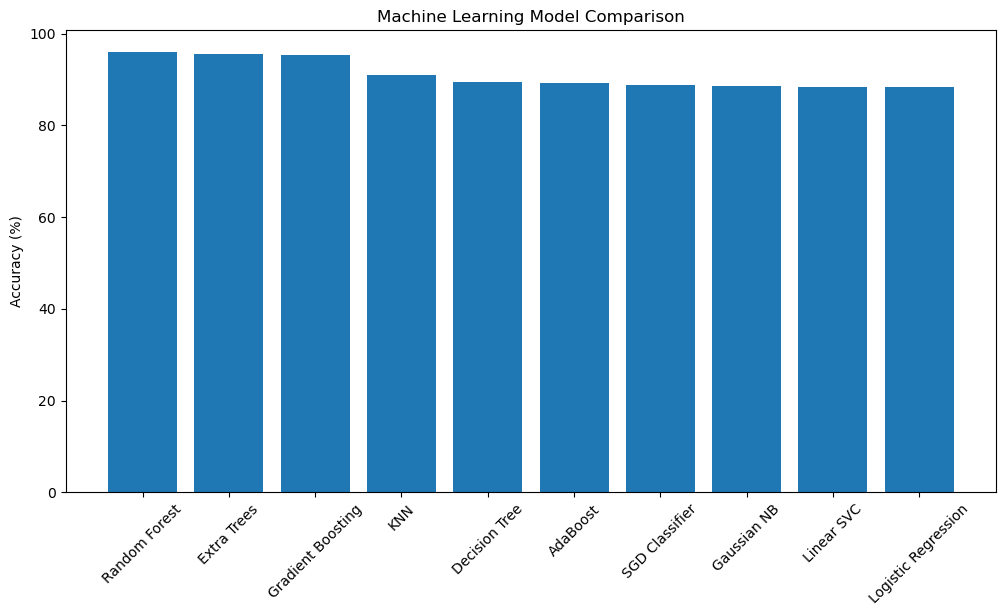

In [12]:

# ============================================
# Accuracy Comparison Graph
# ============================================

plt.figure(figsize=(12,6))

plt.bar(results_df['Model'], results_df['Accuracy'])

plt.xticks(rotation=45)

plt.ylabel('Accuracy (%)')

plt.title('Machine Learning Model Comparison')

plt.show()


In [13]:

# ============================================
# Best Model - Random Forest
# ============================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)

rf_predictions = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_predictions))
print(classification_report(y_test, rf_predictions))


Accuracy: 0.9593863754550181
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     17534
           1       0.78      0.74      0.76      1696

    accuracy                           0.96     19230
   macro avg       0.88      0.86      0.87     19230
weighted avg       0.96      0.96      0.96     19230



In [14]:

# ============================================
# Save Model and Scaler
# ============================================

import joblib

joblib.dump(rf_model, 'random_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved successfully.")


Model and scaler saved successfully.
